<b>Aktywność 8</b><br>
Niezbędne biblioteki: geopandas, mapclassify, matplotlib, numpy, pandas

<b>Ćwiczenie 1.</b> Wczytaj dane z pliku ``YKR_grid_EPSG3067.gpkg`` do obiektu typu GeoDataFrame o nazwie grid.

In [110]:
import geopandas as gpd

### your code ###
grid = gpd.read_file("YKR_grid_EPSG3067.gpkg")

<b>Ćwiczenie 2.</b> Wczytaj dane z pliku ``travel_times_to_5944003_Itis.txt`` do obiektu typu DataFrame o nazwie travel_times_Itis.

In [111]:
import pandas as pd

### your code ###
travel_times_Itis = pd.read_csv("travel_times_to_5944003_Itis.txt", sep=';')

<b>Ćwiczenie 3.</b> Usuń wszystkie kolumny oprócz czterech: from_id, to_id, pt_r_t oraz car_r_t.

In [112]:
### your code ###
travel_times_Itis = travel_times_Itis[['from_id','to_id', 'pt_r_t', 'car_r_t']]

<b>Ćwiczenie 4.</b> Zmień nazwy kolumn pt_r_t i car_r_t na pt_r_t_Itis i car_r_t_Itis.

In [113]:
### your code ###
travel_times_Itis = travel_times_Itis.rename(columns = {'pt_r_t': 'pt_r_t_Itis', 'car_r_t': 'car_r_t_Itis'})

<b>Ćwiczenie 5.</b> Złącz dane ze zmiennych grid i travel_times_Itis po kolumnach YTR_ID i from_id. Zapisz je w zmiennej grid.

In [114]:
### your code ###
grid = grid.merge(travel_times_Itis, left_on='YKR_ID', right_on='from_id', how='inner')

<b>Ćwiczenie 6.</b> Usuń kolumny from_id oraz to_id.

In [115]:
### your code ###
grid = grid.drop(columns = ['from_id', 'to_id'])

<b>Ćwiczenie 7.</b> Wykonaj ponownie ćwiczenia 2-6 dla danych z pliku ``travel_times_to_5902043_Myyrmanni.txt``. Zastosuj analogiczne nazwy zmiennych oraz kolumn.

In [116]:
### your code ###
import pandas as pd

travel_times_Myyrmanni = pd.read_csv("travel_times_to_5902043_Myyrmanni.txt", sep=';')

travel_times_Myyrmanni = travel_times_Myyrmanni[['from_id','to_id', 'pt_r_t', 'car_r_t']]

travel_times_Myyrmanni = travel_times_Myyrmanni.rename(columns = {'pt_r_t': 'pt_r_t_Myyrmanni', 'car_r_t': 'car_r_t_Myyrmanni'})

grid = grid.merge(travel_times_Myyrmanni, left_on='YKR_ID', right_on='from_id', how='inner')

grid = grid.drop(columns = ['from_id', 'to_id'])


<b>Ćwiczenie 8.</b> Zamień wszystkie wartości -1 w zmiennej grid na NaN, a następnie usuń te rekordy, które zawierają wartości NaN.

In [117]:
import numpy as np

### your code ###
grid = grid.replace(-1, np.nan)
grid = grid.dropna()

<b>Ćwiczenie 9.</b> Zamień liczbę minut na przedziały czasowe o wartościach 5, 10, 15, ..., 50, 55, 60. Zapisz rezultaty w kolumnach pt_r_t_cl_Itis, car_r_t_cl_Itis, pt_r_t_cl_Myyrmanni, pt_r_t_cl_Myyrmanni.

In [118]:
import mapclassify

classifier = mapclassify.UserDefined.make(bins = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])

### your code ###
grid['pt_r_t_cl_Itis'] = classifier(grid['pt_r_t_Itis'])
grid['car_r_t_cl_Itis'] = classifier(grid['car_r_t_Itis'])
grid['pt_r_t_cl_Myyrmanni'] = classifier(grid['pt_r_t_Myyrmanni'])
grid['car_r_t_cl_Myyrmanni'] = classifier(grid['car_r_t_Myyrmanni'])
grid

,YKR_ID,geometry,pt_r_t_Itis,car_r_t_Itis,pt_r_t_Myyrmanni,car_r_t_Myyrmanni,pt_r_t_cl_Itis,car_r_t_cl_Itis,pt_r_t_cl_Myyrmanni,car_r_t_cl_Myyrmanni
0,5785640,"POLYGON ((382000 6697750, 381750 6697750, 3817...",132.0,50.0,90.0,39.0,12,9,12,7
1,5785641,"POLYGON ((382250 6697750, 382000 6697750, 3820...",135.0,51.0,93.0,39.0,12,10,12,7
2,5785642,"POLYGON ((382500 6697750, 382250 6697750, 3822...",137.0,58.0,95.0,47.0,12,11,12,9
3,5785643,"POLYGON ((382750 6697750, 382500 6697750, 3825...",141.0,57.0,99.0,51.0,12,11,12,10
4,5787544,"POLYGON ((381250 6697500, 381000 6697500, 3810...",125.0,50.0,83.0,38.0,12,9,12,7
...,...,...,...,...,...,...,...,...,...,...
13225,6016697,"POLYGON ((372750 6665500, 372500 6665500, 3725...",81.0,59.0,97.0,53.0,12,11,12,10
13226,6016698,"POLYGON ((373000 6665500, 372750 6665500, 3727...",79.0,60.0,95.0,54.0,12,11,12,10
13227,6016699,"POLYGON ((373250 6665500, 373000 6665500, 3730...",81.0,62.0,97.0,56.0,12,12,12,11
13229,6018253,"POLYGON ((372750 6665250, 372500 6665250, 3725...",84.0,61.0,100.0,55.0,12,12,12,10


<b>Ćwiczenie 10.</b> Utwórz zestaw wykresów 2x2, gdzie po lewej stronie będzie transport publiczny, po prawej podróż samochodem, u góry miasto Itis, a na dole miasto Myyrmanni.

Text(0.5, 1.0, 'Transport samochodem Myyrmanni')

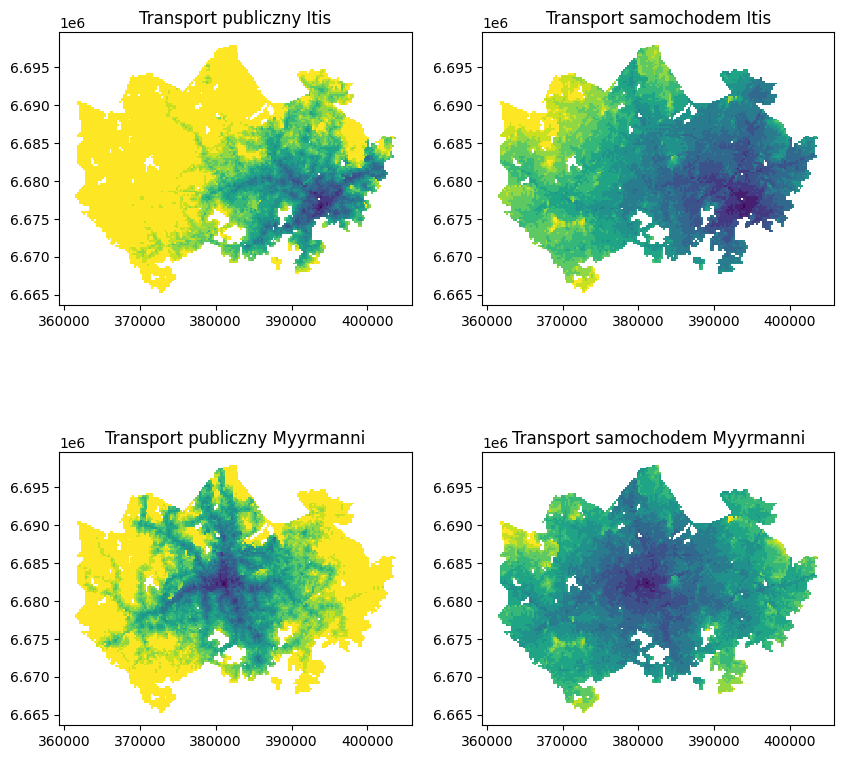

In [126]:
import matplotlib.pyplot as plt

### your code ###
fig, axes = plt.subplots(2, 2, figsize = (10,10))
grid.plot(ax = axes[0, 0], column = 'pt_r_t_cl_Itis')
grid.plot(ax = axes[0, 1], column = 'car_r_t_cl_Itis')
grid.plot(ax = axes[1, 0], column = 'pt_r_t_cl_Myyrmanni')
grid.plot(ax = axes[1, 1], column = 'car_r_t_cl_Myyrmanni')

axes[0, 0].set_title('Transport publiczny Itis')
axes[0, 1].set_title('Transport samochodem Itis')
axes[1, 0].set_title('Transport publiczny Myyrmanni')
axes[1, 1].set_title('Transport samochodem Myyrmanni')

<b>Ćwiczenie 11.</b> Utwórz obiekt typu GeoDataFrame o nazwie grid2, który będzie zawierał następujące kolumny: YTR_ID, geometry, pt_r_t_Jumbo, pt_r_t_Dixi, pt_r_t_Myyrmanni, pt_r_t_Itis, pt_r_t_Forum, pt_r_t_IsoOmena oraz pt_r_t_Ruoholahti. Zamień wszystkie wartości -1 w zmiennej grid2 na NaN, a następnie usuń te rekordy, które zawierają wartości NaN.

In [127]:
### your code ###
import pandas as pd

grid2 = gpd.read_file("YKR_grid_EPSG3067.gpkg")

travel_times = pd.read_csv("travel_times_to_5878070_Jumbo.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Jumbo'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

travel_times = pd.read_csv("travel_times_to_5878087_Dixi.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Dixi'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

travel_times = pd.read_csv("travel_times_to_5902043_Myyrmanni.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Myyrmanni'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

travel_times = pd.read_csv("travel_times_to_5944003_Itis.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Itis'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

travel_times = pd.read_csv("travel_times_to_5975373_Forum.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Forum'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

travel_times = pd.read_csv("travel_times_to_5978593_Iso_Omena.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Iso_Omena'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

travel_times = pd.read_csv("travel_times_to_5980260_Ruoholahti.txt", sep=';')
travel_times = travel_times[['from_id','to_id', 'pt_r_t']]
travel_times = travel_times.rename(columns = {'pt_r_t': 'pt_r_t_Ruoholahti'})
grid2 = grid2.merge(travel_times, left_on='YKR_ID', right_on='from_id', how='inner')
grid2 = grid2.drop(columns = ['from_id', 'to_id'])

grid2 = grid2.replace(-1, np.nan)
grid2 = grid2.dropna()

<b>Ćwiczenie 12.</b> Dla każdego rekordu w zmiennej grid2 znajdź najkrótszy czas podróży do centrum handlowego oraz najbliższe centrum handlowe. Rezultaty zapisz w kolumnach min_time oraz shopping_centre.

In [134]:
### your code ###
grid2['min_time'] = grid2[['pt_r_t_Jumbo', 'pt_r_t_Dixi', 'pt_r_t_Myyrmanni', 'pt_r_t_Itis', 'pt_r_t_Forum', 'pt_r_t_Iso_Omena', 'pt_r_t_Ruoholahti']].min(axis = 1)
grid2['shopping_centre'] = grid2[['pt_r_t_Jumbo', 'pt_r_t_Dixi', 'pt_r_t_Myyrmanni', 'pt_r_t_Itis', 'pt_r_t_Forum', 'pt_r_t_Iso_Omena', 'pt_r_t_Ruoholahti']].idxmin(axis = 1)
grid2

,YKR_ID,geometry,pt_r_t_Jumbo,pt_r_t_Dixi,pt_r_t_Myyrmanni,pt_r_t_Itis,pt_r_t_Forum,pt_r_t_Iso_Omena,pt_r_t_Ruoholahti,min_time,shopping_centre
0,5785640,"POLYGON ((382000 6697750, 381750 6697750, 3817...",101.0,102.0,90.0,132.0,110.0,141.0,118.0,90.0,pt_r_t_Myyrmanni
1,5785641,"POLYGON ((382250 6697750, 382000 6697750, 3820...",108.0,109.0,93.0,135.0,113.0,143.0,121.0,93.0,pt_r_t_Myyrmanni
2,5785642,"POLYGON ((382500 6697750, 382250 6697750, 3822...",109.0,111.0,95.0,137.0,115.0,145.0,123.0,95.0,pt_r_t_Myyrmanni
3,5785643,"POLYGON ((382750 6697750, 382500 6697750, 3825...",114.0,115.0,99.0,141.0,119.0,149.0,127.0,99.0,pt_r_t_Myyrmanni
4,5787544,"POLYGON ((381250 6697500, 381000 6697500, 3810...",98.0,99.0,83.0,125.0,103.0,134.0,111.0,83.0,pt_r_t_Myyrmanni
...,...,...,...,...,...,...,...,...,...,...,...
13225,6016697,"POLYGON ((372750 6665500, 372500 6665500, 3725...",111.0,81.0,97.0,81.0,54.0,40.0,50.0,40.0,pt_r_t_Iso_Omena
13226,6016698,"POLYGON ((373000 6665500, 372750 6665500, 3727...",109.0,79.0,95.0,79.0,52.0,38.0,48.0,38.0,pt_r_t_Iso_Omena
13227,6016699,"POLYGON ((373250 6665500, 373000 6665500, 3730...",110.0,81.0,97.0,81.0,54.0,40.0,50.0,40.0,pt_r_t_Iso_Omena
13229,6018253,"POLYGON ((372750 6665250, 372500 6665250, 3725...",114.0,84.0,100.0,84.0,57.0,43.0,53.0,43.0,pt_r_t_Iso_Omena


<b>Ćwiczenie 13.</b> Utwórz zestaw wykresów 2x1, gdzie po lewej stronie dla każdego grida będzie zaznaczone najbliższe centrum handlowe, a po prawej stronie najkrótszy czas podróży do centrum handlowego.

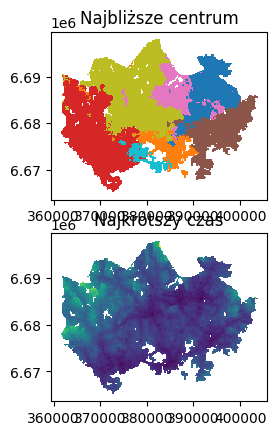

In [139]:
### your code ###
fig, axs = plt.subplots(2, 1)
grid2.plot(ax = axs[0], column = 'shopping_centre')
grid2.plot(ax = axs[1], column = 'min_time')

axs[0].set_title('Najbliższe centrum')
axs[1].set_title('Najkrótszy czas')
plt.show()